In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Final_Augmented_dataset_Diseases_and_Symptoms.csv")

In [4]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#checking shape
df.shape

(246945, 378)

In [6]:
#checking coloumns
df.columns

Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='str', length=378)

In [7]:
#checking missing values
df.isnull().sum()

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64

In [8]:
#check disease distribution
df['diseases'].value_counts()

diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
foreign body in the nose             1
thalassemia                          1
open wound of the head               1
rocky mountain spotted fever         1
kaposi sarcoma                       1
Name: count, Length: 773, dtype: int64

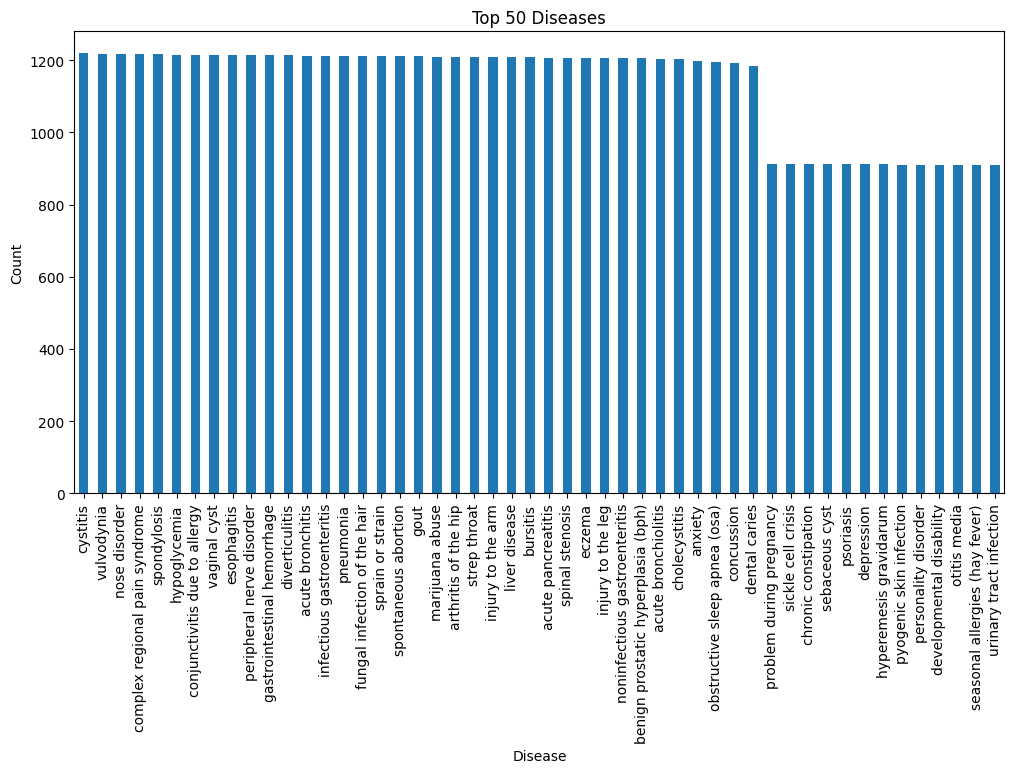

In [18]:
#plot top disease
top_diseases = df['diseases'].value_counts().head(50)

plt.figure(figsize=(12,6))
top_diseases.plot(kind='bar')
plt.title("Top 50 Diseases")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [11]:
#separate features and labels

X = df.drop("diseases", axis=1)
y = df["diseases"]

In [12]:
#encoding disease labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [ ]:
TRAIN TEST SPLITS

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [14]:
#CHECK SHAPES
print(X_train.shape)
print(X_test.shape)

(197556, 377)
(49389, 377)


In [15]:
#SAVE LABEL ENCODER

import joblib

joblib.dump(label_encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']

In [16]:
#SAVE PROCESSED DATA
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)